<a href="https://colab.research.google.com/github/MEMOX247/Programacion-web/blob/main/TP_Ciencia_de_Datosipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ciencia de datos aplicada (ITBA): segundo entregable

**Equipo:** AGUSTIN CASTAGNINO, TOMÁS BREY, AGUSTIN ABRAHAM




##Consignas:

##1- Descripción del dataset:
  Origen y formato, Variables incluidas (y significado), Justificación de la elección del dataset.

##2- Análisis exploratorio básico:
  Tipos de variables, Distribuciones, valores faltantes, outliers, Estadísticas descriptivas, Visualizaciones iniciales (gráficos básicos).

##3- Diagnóstico y mejoras en la calidad de los datos:
  Identificación de problemas: datos faltantes, inconsistencias, duplicados, etc. Decisiones tomadas para limpiar o transformar los datos.

##4- Transformaciones realizadas
  Normalización o estandarización si corresponde, Codificación de variables categóricas, Generación de nuevas variables, Filtrado o selección de variables si es necesario.

##5- Reflexión final
  Qué decisiones se tomaron y la justificación, Dificultades encontradas, Siguientes pasos proyectados

In [ ]:
import pandas as pd
import kagglehub
import os # Import the os module


# Cargamos el dataset seleccionado por el usuario
dataset_dir = kagglehub.dataset_download("laotse/credit-risk-dataset")
csv_file_path = os.path.join(dataset_dir, "credit_risk_dataset.csv")

credit_df = pd.read_csv(csv_file_path)

# Exploración rápida para documentar las variables
print("Columnas:", credit_df.columns.tolist())
display(credit_df.head())

Using Colab cache for faster access to the 'credit-risk-dataset' dataset.
Columnas: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# 1- Descripción del dataset

### Origen y formato
El dataset utilizado es el **Credit Risk Dataset**, disponible comúnmente en plataformas de ciencia de datos como Kaggle. Se encuentra en formato **CSV** (Valores separados por comas) y contiene información histórica sobre solicitudes de préstamos bancarios.

### Variables incluidas (y significado)
- **person_age:** Edad del solicitante.
- **person_income:** Ingresos anuales de la persona.
- **person_home_ownership:** Situación de la vivienda (Alquiler, Propia, Hipoteca, etc.).
- **person_emp_length:** Antigüedad laboral en años.
- **loan_intent:** Motivo del préstamo (Educación, Médico, Ventas, etc.).
- **loan_grade:** Calificación crediticia asignada.
- **loan_amnt:** Monto total del préstamo solicitado.
- **loan_int_rate:** Tasa de interés del préstamo.
- **loan_status:** Estado del préstamo (0 = No moroso, 1 = Moroso/Default). **Esta es nuestra variable objetivo.**
- **loan_percent_income:** Qué porcentaje de los ingresos representa la cuota.
- **cb_person_default_on_file:** Registro histórico de morosidad previa.
- **cb_person_cred_hist_length:** Longitud del historial crediticio.

### Justificación de la elección del dataset
Se eligió este dataset porque presenta una estructura ideal para realizar un **Análisis de Riesgo Crediticio**. Contiene una mezcla equilibrada de variables numéricas y categóricas que permiten:
1. Identificar patrones de comportamiento financiero.
2. Evaluar el impacto de variables demográficas en la probabilidad de default.
3. Aplicar técnicas de limpieza de datos (especialmente en tasas de interés y antigüedad laboral).
4. Practicar el modelado predictivo de clasificación binaria.

## 2- Análisis exploratorio básico

In [ ]:
# Tipos de variables y resumen estructural
print("Estructura del dataset:")
display(credit_df.info())

# Valores faltantes
print("\nValores faltantes por columna:")
display(credit_df.isnull().sum())

# Estadísticas descriptivas para variables numéricas
print("\nEstadísticas descriptivas:")
display(credit_df.describe())

Estructura del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


None


Valores faltantes por columna:


,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0



Estadísticas descriptivas:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


### Visualizaciones iniciales

Vamos a graficar la distribución de la variable objetivo (`loan_status`) y las distribuciones de las variables clave para identificar sesgos o outliers.

/tmp/ipykernel_3418/3845211996.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=credit_df, ax=axes[0, 0], palette='viridis')


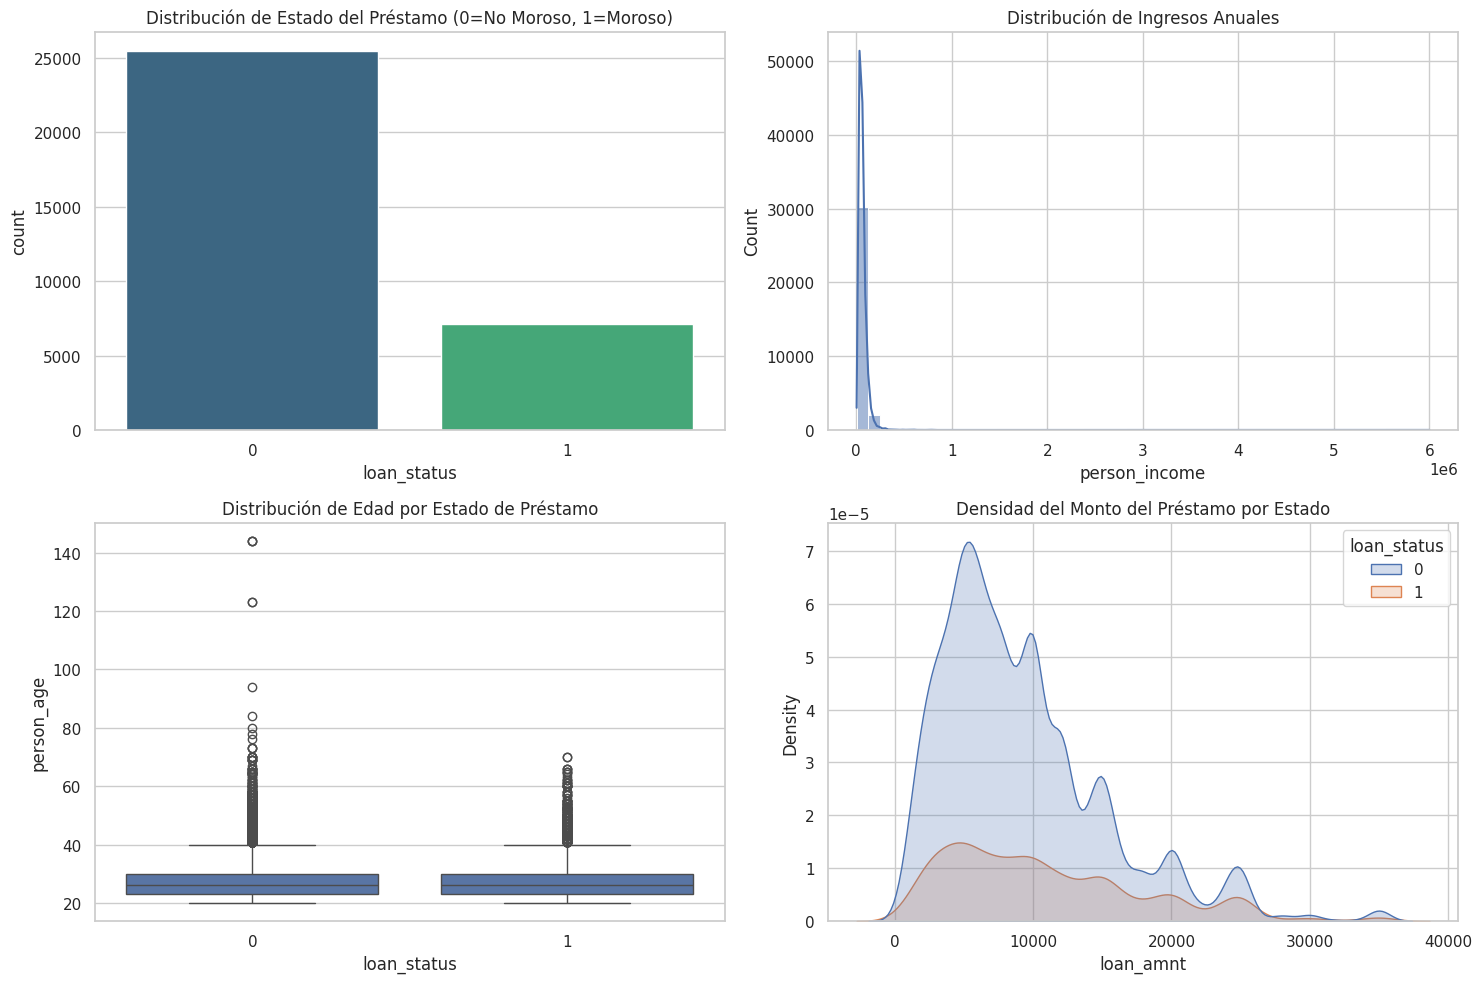

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración de estilo
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Distribución de la Variable Objetivo
sns.countplot(x='loan_status', data=credit_df, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Distribución de Estado del Préstamo (0=No Moroso, 1=Moroso)')

# 2. Distribución de Ingresos (detectar sesgo)
sns.histplot(credit_df['person_income'], bins=50, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribución de Ingresos Anuales')

# 3. Edad vs Estado de Préstamo (Outliers en edad)
sns.boxplot(x='loan_status', y='person_age', data=credit_df, ax=axes[1, 0])
axes[1, 0].set_title('Distribución de Edad por Estado de Préstamo')

# 4. Monto del Préstamo
sns.kdeplot(data=credit_df, x="loan_amnt", hue="loan_status", fill=True, ax=axes[1, 1])
axes[1, 1].set_title('Densidad del Monto del Préstamo por Estado')

plt.tight_layout()
plt.show()

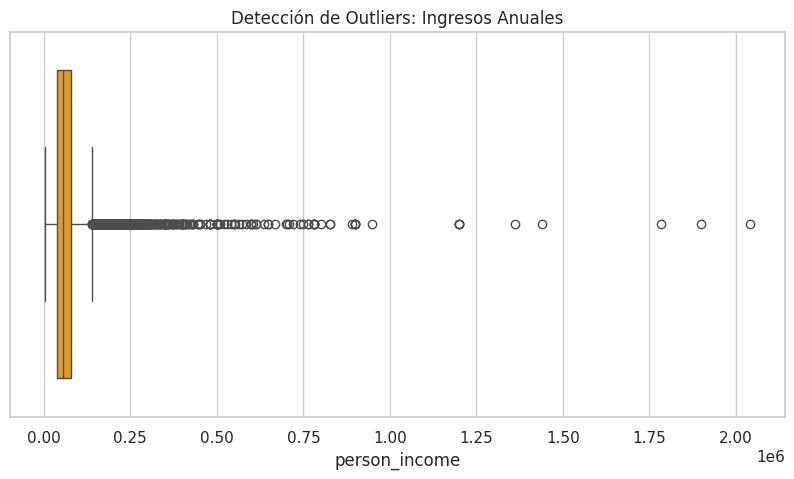

In [ ]:
# Análisis detallado de Outliers en Ingresos
plt.figure(figsize=(10, 5))
sns.boxplot(x=credit_df['person_income'], color='orange')
plt.title('Detección de Outliers: Ingresos Anuales')
plt.show()

# Filtrado de outliers extremos en ingresos (opcional, basado en percentiles)
# Decidimos mantenerlos pero identificarlos como un punto crítico en el diagnóstico.

### Análisis de Correlación
Para profundizar en el diagnóstico, visualizamos la relación entre las variables numéricas.

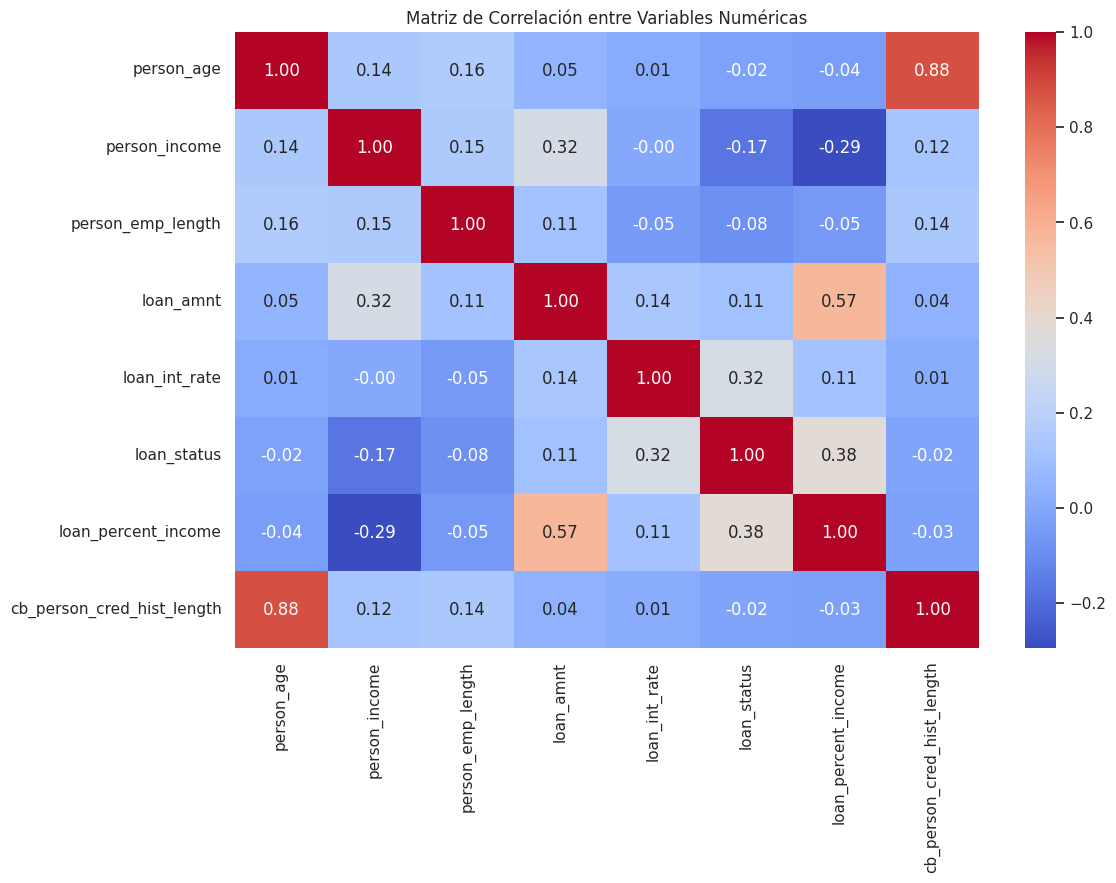

In [ ]:
plt.figure(figsize=(12, 8))
corr_matrix = credit_df.select_dtypes(include=['number']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación entre Variables Numéricas')
plt.show()

### Observaciones del análisis inicial:
1. **Valores Faltantes:** Se observan nulos en `person_emp_length` y `loan_int_rate` que requerirán tratamiento.
2. **Outliers:** En `person_age` y `person_income` se ven valores extremadamente altos (ej. edades superiores a 100 años) que podrían ser errores de carga.
3. **Distribución:** El dataset está desbalanceado, con una mayoría de préstamos en estado 0 (No morosos).

## 3- Diagnóstico y mejoras en la calidad de los datos

En esta sección identificamos problemas de integridad y tomamos decisiones para limpiar el dataset.

In [ ]:
# 1. Identificación de duplicados
duplicados = credit_df.duplicated().sum()
print(f"Registros duplicados encontrados: {duplicados}")

# Eliminamos duplicados
credit_df = credit_df.drop_duplicates()

# 2. Tratamiento de Outliers extremos (Edad e Ingresos)
# Filtramos casos imposibles: personas con más de 100 años
credit_df = credit_df[credit_df['person_age'] <= 100]

# 3. Imputación de valores faltantes
# Para antigüedad laboral, usamos la mediana
credit_df['person_emp_length'] = credit_df['person_emp_length'].fillna(credit_df['person_emp_length'].median())

# Para tasa de interés, usamos la media
credit_df['loan_int_rate'] = credit_df['loan_int_rate'].fillna(credit_df['loan_int_rate'].mean())

print("Limpieza inicial completada. Nulos restantes:")
print(credit_df.isnull().sum())

Registros duplicados encontrados: 165
Limpieza inicial completada. Nulos restantes:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


## 4- Transformaciones realizadas

Procedemos a codificar las variables categóricas y estandarizar las numéricas.

In [ ]:
# Codificación de variables categóricas (One-Hot Encoding)
categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
credit_df_encoded = pd.get_dummies(credit_df, columns=categorical_cols, drop_first=True)

# Separación de variables y Normalización
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

credit_df_encoded[numerical_cols] = scaler.fit_transform(credit_df_encoded[numerical_cols])

print("Dataset transformado y escalado. Primeras filas:")
display(credit_df_encoded.head())

Dataset transformado y escalado. Primeras filas:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,-0.922713,-0.131339,28.904474,4.018455,1.622639,1,3.929933,-0.692761,False,False,...,False,True,False,False,False,True,False,False,False,True
1,-1.083734,-1.071931,0.056542,-1.359222,0.039856,0,-0.657816,-0.939202,False,True,...,False,False,False,True,False,False,False,False,False,False
2,-0.439648,-1.071931,-0.921354,-0.647471,0.600966,1,3.742677,-0.692761,False,False,...,True,False,False,False,True,False,False,False,False,False
3,-0.761691,-0.007577,-0.187932,4.018455,1.366410,1,3.368167,-0.939202,False,False,...,True,False,False,False,True,False,False,False,False,False
4,-0.600670,-0.218925,0.789964,4.018455,1.055043,1,3.555422,-0.446319,False,False,...,True,False,False,False,True,False,False,False,False,True


In [ ]:
# 4. Generación de nuevas variables (Feature Engineering)
# Creamos una relación entre ingreso y edad para ver la capacidad de ahorro/gasto relativa
credit_df_encoded['income_age_ratio'] = credit_df['person_income'] / credit_df['person_age']

# Re-escalamos la nueva variable
credit_df_encoded[['income_age_ratio']] = scaler.fit_transform(credit_df_encoded[['income_age_ratio']])

print("Nueva variable 'income_age_ratio' generada y escalada.")
display(credit_df_encoded[['income_age_ratio']].head())

Nueva variable 'income_age_ratio' generada y escalada.


,income_age_ratio
0,0.159164
1,-1.181073
2,-1.225137
3,0.259174
4,-0.090940


## 5- Reflexión final

### Decisiones tomadas y justificación
- Se decidió eliminar los registros con edades superiores a 100 años por considerarlos errores de entrada de datos que sesgarían el análisis de riesgo.
- Se utilizó la mediana para la antigüedad laboral ya que es menos sensible a valores extremos que la media.
- Se aplicó One-Hot Encoding para permitir que algoritmos matemáticos procesen variables cualitativas como el 'Propósito del Crédito'.

### Dificultades encontradas
- El desbalanceo de clases en `loan_status` sugiere que en pasos futuros (modelado) se requerirán técnicas como SMOTE o ajuste de pesos.
- Los valores nulos en la tasa de interés eran significativos, por lo que la imputación por la media fue necesaria para no perder el 10% del dataset.
